# Outliers

Outliers are data points that are significantly different from the rest of the data.

Outliers can:
    Increase or decrease the mean drastically
    Affect model performance
    Distort statistical analysis
    Cause overfitting in some ML models

In [3]:
import numpy as np 
arr = [2,3,4,6,7,8,9,12,13,16,17,23,25,27,34,37,201]
arr

[2, 3, 4, 6, 7, 8, 9, 12, 13, 16, 17, 23, 25, 27, 34, 37, 201]

In [ ]:
Q1 = np.percentile(arr,25)
Q3 = np.percentile(arr,75)
IQR = Q3 - Q1
IQR


np.float64(18.0)

In [13]:
UF = Q3 + (1.5*IQR)
LF = Q1 - (1.5*IQR)
UF,LF

(np.float64(52.0), np.float64(-20.0))

In [12]:
for i in arr:
    if i > UF or i < LF:
        print(i)

201


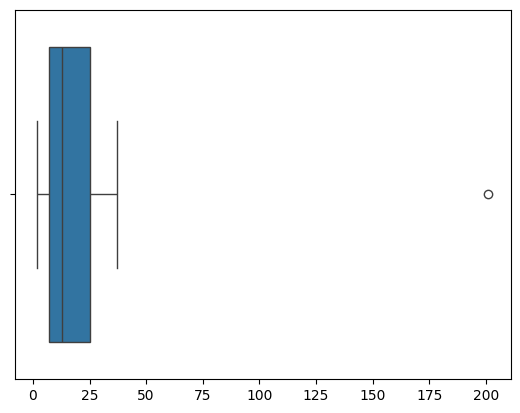

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=arr)
plt.show()

In [15]:
l = []
for i in arr:
    if i >= LF and i <= UF:
        l.append(i)
arr2 = np.array(l)

In [16]:
print(arr2)

[ 2  3  4  6  7  8  9 12 13 16 17 23 25 27 34 37]


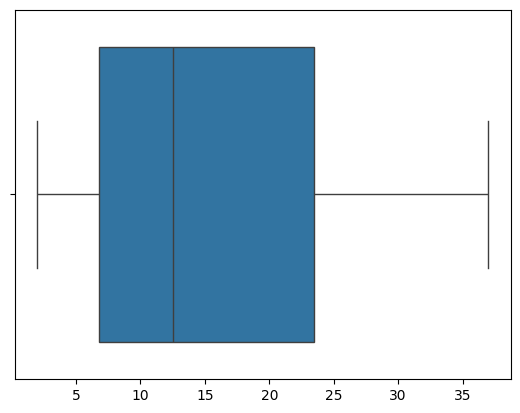

In [18]:
sns.boxplot(x=arr2)
plt.show()

# 1. Empirical Rule (68-95-99.7 Rule)

Used for Normal Distribution.

It states:

68% of data lies within 1 Standard Deviation (σ) from the mean.

95% of data lies within 2 Standard Deviations (σ) from the mean.

99.7% of data lies within 3 Standard Deviations (σ) from the mean.

Example:

Mean = 50
Standard Deviation = 10

μ = 50

μ ± 1σ = 40 to 60   → 68% data

μ ± 2σ = 30 to 70   → 95% data

μ ± 3σ = 20 to 80   → 99.7% data

# 2. Z-Score

A Z-score tells how many standard deviations a value is away from the mean.

In [19]:
# normal code 
mean = 50
std = 10
x = 70

z_score = (x - mean) / std

print(z_score)

2.0


In [20]:
#using scipy
from scipy.stats import zscore

data = [10, 20, 30, 40, 50]

z_scores = zscore(data)

print(z_scores)

[-1.41421356 -0.70710678  0.          0.70710678  1.41421356]


# Finding Outliers with Z-Score

In [21]:
from scipy.stats import zscore
import numpy as np

data = [10, 12, 15, 18, 20, 22, 100]

z = np.abs(zscore(data))

outliers = np.where(z > 3)

print(outliers)

(array([], dtype=int64),)


# Covariance

Covariance tells us whether two variables move together or in opposite directions.

Interpretation

Covariance Value	         Meaning

Positive (+)	    Both variables increase/decrease together

Negative (-)	    One increases while the other decreases

Zero (0)	    No linear relationship

In [22]:
import numpy as np

x = [1, 2, 3, 4]
y = [20, 40, 60, 80]

cov = np.cov(x, y)

print(cov)

[[  1.66666667  33.33333333]
 [ 33.33333333 666.66666667]]


# Correlation

Correlation measures:

How strong the relationship is between two variables.

Unlike covariance, correlation is always between -1 and +1.

Interpretation

Correlation (r)	Meaning

+1	Perfect positive relationship

+0.8	Strong positive relationship

0	No relationship

-0.8	Strong negative relationship

-1	Perfect negative relationship

In [23]:
import numpy as np

x = [1, 2, 3, 4]
y = [20, 40, 60, 80]

corr = np.corrcoef(x, y)

print(corr)

[[1. 1.]
 [1. 1.]]


In [24]:
import pandas as pd

df = pd.DataFrame({
    'hours':[1,2,3,4],
    'marks':[20,40,60,80]
})

print(df.corr())

       hours  marks
hours    1.0    1.0
marks    1.0    1.0


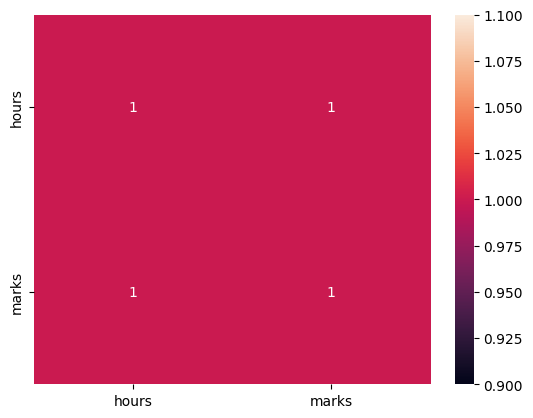

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.corr(), annot=True)

plt.show()